<a href="https://colab.research.google.com/github/LauvB/analisis-biomarcadores-alzheimer/blob/main/analisis_biomarcadores_alzheimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis exploratorio de biomarcadores asociados a la progresión clínica del Alzheimer

## Introducción

Este proyecto presenta un análisis exploratorio realizado con Python sobre un
conjunto de características derivadas de un modelo neurocomputacional orientado
al estudio de la progresión clínica del Alzheimer.

El dataset contiene biomarcadores espectrales, métricas de conectividad
funcional y estructural, parámetros asociados al modelo Wilson-Cowan y variables
ordinales relacionadas con la etapa clínica.

El objetivo del análisis es explorar la distribución de estas variables y estudiar
su asociación con las diferentes etapas clínicas representadas en el conjunto
de datos.

> **Nota:** Por razones de privacidad y condiciones de uso de los datos de ADNI, este proyecto no contiene datos individuales originales de pacientes. El análisis utiliza características agregadas derivadas de mi trabajo de grado.

## Objetivo

Analizar exploratoriamente el comportamiento de biomarcadores espectrales y
métricas de conectividad en relación con un índice ordinal de severidad clínica,
utilizando técnicas de análisis y visualización de datos en Python.

## Preguntas de análisis

1. ¿Cómo se distribuyen las características espectrales entre las etapas clínicas?
2. ¿Cómo varían las bandas de frecuencia delta, theta, alpha, beta y gamma?
3. ¿Cómo se comportan `theta_alpha_ratio` y `slowing`?
4. ¿Qué patrones presentan las métricas de conectividad funcional y estructural?
5. ¿Qué biomarcadores presentan mayor asociación con el índice de severidad?
6. ¿Existen diferencias entre las cuatro etapas clínicas?

## Diccionario de variables

| Variable            | Categoría                | Descripción                               |
| ------------------- | ------------------------ | ----------------------------------------- |
| `subject_id`        | Identificación           | Identificador interno del registro        |
| `P_E`               | Modelo                   | Parámetro del modelo Wilson-Cowan         |
| `G`                 | Modelo                   | Parámetro del modelo Wilson-Cowan         |
| `noise_std`         | Modelo                   | Desviación estándar del ruido             |
| `best_error`        | Modelo                   | Error obtenido durante la calibración     |
| `BP_delta`          | Espectral                | Potencia relativa de delta                |
| `BP_theta`          | Espectral                | Potencia relativa de theta                |
| `BP_alpha`          | Espectral                | Potencia relativa de alpha                |
| `BP_beta`           | Espectral                | Potencia relativa de beta                 |
| `BP_gamma`          | Espectral                | Potencia relativa de gamma                |
| `theta_alpha_ratio` | Derivado                 | Relación entre potencia theta y alpha     |
| `slowing`           | Derivado                 | Indicador derivado de actividad lenta     |
| `FC_strength`       | Conectividad funcional   | Fuerza global de conectividad             |
| `FC_clustering`     | Conectividad funcional   | Coeficiente global de clustering          |
| `FC_efficiency`     | Conectividad funcional   | Eficiencia global                         |
| `SC_strength`       | Conectividad estructural | Fuerza global de conectividad estructural |
| `SC_density`        | Conectividad estructural | Densidad global de conectividad           |
| `label`             | Clínica                  | Categoría: CN, EMCI, MCI o AD             |
| `severity_index`    | Clínica ordinal          | Índice de severidad de 0 a 3              |


## Preparación y calidad de datos

### 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 2.2.3
NumPy: 2.1.3


### 2. Cargar el dataset

In [4]:
ruta_data = 'https://raw.githubusercontent.com/LauvB/analisis-biomarcadores-alzheimer/refs/heads/main/data/features_16_subjects.csv'
df = pd.read_csv(ruta_data)
df.head()

,subject_id,P_E,G,noise_std,best_error,BP_delta,BP_theta,BP_alpha,BP_beta,BP_gamma,theta_alpha_ratio,slowing,FC_strength,FC_clustering,FC_efficiency,SC_strength,SC_density,label,severity_index
0,CN_1,1.0,0.6,0.05,0.148058,0.074160,0.335303,0.325402,0.219438,0.045697,1.030427,0.409463,0.181732,0.010411,1.0,3142.296296,1.055556,CN,0
1,CN_2,1.0,0.6,0.05,0.149269,0.022695,0.277387,0.407602,0.220922,0.071395,0.680533,0.300081,0.180682,0.002584,1.0,3955.390625,1.017857,CN,0
2,CN_3,1.0,0.6,0.05,0.149068,0.147381,0.339109,0.272498,0.208451,0.032561,1.244447,0.486490,0.233364,0.030030,1.0,3510.921875,1.107143,CN,0
3,CN_4,1.0,0.6,0.05,0.149414,0.307705,0.312101,0.188532,0.172892,0.018769,1.655423,0.619806,0.990050,0.988580,1.0,3470.109375,1.089286,CN,0
4,EMCI_1,1.0,0.6,0.05,0.075037,0.152642,0.341394,0.266467,0.205890,0.033607,1.281188,0.494036,0.213299,0.033519,1.0,8774.222222,1.000000,EMCI,1


### 3. Información general del dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         16 non-null     object 
 1   P_E                16 non-null     float64
 2   G                  16 non-null     float64
 3   noise_std          16 non-null     float64
 4   best_error         16 non-null     float64
 5   BP_delta           16 non-null     float64
 6   BP_theta           16 non-null     float64
 7   BP_alpha           16 non-null     float64
 8   BP_beta            16 non-null     float64
 9   BP_gamma           16 non-null     float64
 10  theta_alpha_ratio  16 non-null     float64
 11  slowing            16 non-null     float64
 12  FC_strength        16 non-null     float64
 13  FC_clustering      16 non-null     float64
 14  FC_efficiency      16 non-null     float64
 15  SC_strength        16 non-null     float64
 16  SC_density         16 non-nu

### 4. Estadística descriptiva

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
P_E,16.0,1.237500,0.344238,1.000000,1.000000,1.000000,1.350000,1.800000
G,16.0,0.750000,0.268328,0.600000,0.600000,0.600000,0.750000,1.200000
noise_std,16.0,0.106250,0.075000,0.050000,0.050000,0.050000,0.200000,0.200000
best_error,16.0,0.071989,0.051490,0.011201,0.036821,0.074707,0.093825,0.149414
BP_delta,16.0,0.165614,0.083482,0.022695,0.147347,0.152596,0.157479,0.322465
BP_theta,16.0,0.334835,0.019809,0.277387,0.331946,0.341219,0.345470,0.355921
BP_alpha,16.0,0.270093,0.055458,0.187102,0.266175,0.268370,0.273239,0.407602
BP_beta,16.0,0.194400,0.019833,0.150022,0.182789,0.196296,0.207429,0.220922
BP_gamma,16.0,0.035057,0.012373,0.017737,0.031458,0.033329,0.037685,0.071395
theta_alpha_ratio,16.0,1.288249,0.253689,0.680533,1.244986,1.280715,1.303636,1.712980


### 5. Valores faltantes

In [7]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percentage": df.isnull().mean() * 100
})

missing.sort_values("missing", ascending=False)

,missing,percentage
subject_id,0,0.0
P_E,0,0.0
G,0,0.0
noise_std,0,0.0
best_error,0,0.0
BP_delta,0,0.0
BP_theta,0,0.0
BP_alpha,0,0.0
BP_beta,0,0.0
BP_gamma,0,0.0


### 6. Registros duplicados

In [8]:
df.duplicated().sum()

np.int64(0)

No se identificaron registros duplicados en el conjunto de datos.

### 7. Categorías clínicas

In [9]:
df["label"].value_counts()

,count
label,
CN,4
EMCI,4
MCI,4
AD,4


Categorías ordedanas según la progresión del Alzheimer.

In [10]:
orden_clinico = ["CN", "EMCI", "MCI", "AD"]

df["label"] = pd.Categorical(
    df["label"],
    categories=orden_clinico,
    ordered=True
)

### 8. Validación del índice de severidad

In [11]:
pd.crosstab(df["label"], df["severity_index"])

severity_index,0,1,2,3
label,,,,
CN,4,0,0,0
EMCI,0,4,0,0
MCI,0,0,4,0
AD,0,0,0,4


### 9. Resumen de auditoría

In [12]:
audit = pd.DataFrame({
    "Métrica": [
        "Registros",
        "Variables",
        "Valores faltantes",
        "Registros duplicados",
        "Categorías clínicas"
    ],
    "Resultado": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["label"].nunique()
    ]
})

audit

,Métrica,Resultado
0,Registros,16
1,Variables,19
2,Valores faltantes,0
3,Registros duplicados,0
4,Categorías clínicas,4


## Análisis exploratorio de biomarcadores


### 1. Variables expectrales

In [13]:
spectral_features = [
    "BP_delta",
    "BP_theta",
    "BP_alpha",
    "BP_beta",
    "BP_gamma"
]

df[spectral_features].describe().T

,count,mean,std,min,25%,50%,75%,max
BP_delta,16.0,0.165614,0.083482,0.022695,0.147347,0.152596,0.157479,0.322465
BP_theta,16.0,0.334835,0.019809,0.277387,0.331946,0.341219,0.345470,0.355921
BP_alpha,16.0,0.270093,0.055458,0.187102,0.266175,0.268370,0.273239,0.407602
BP_beta,16.0,0.194400,0.019833,0.150022,0.182789,0.196296,0.207429,0.220922
BP_gamma,16.0,0.035057,0.012373,0.017737,0.031458,0.033329,0.037685,0.071395


### 2. Comparación las bandas según la etapa clínica



In [14]:
def plot_biomarker_by_stage(data, variable, title):
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=data,
        x="label",
        y=variable,
        order=orden_clinico
    )

    sns.stripplot(
        data=data,
        x="label",
        y=variable,
        order=orden_clinico,
        color="black",
        alpha=0.7
    )

    plt.title(title)
    plt.xlabel("Etapa clínica")
    plt.ylabel(variable)

    plt.show()

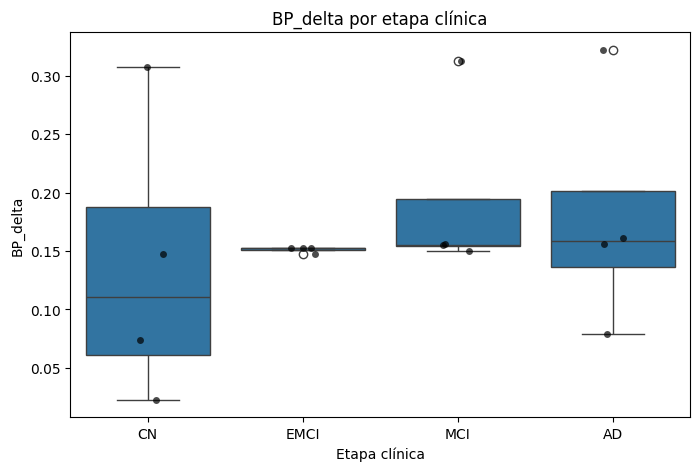

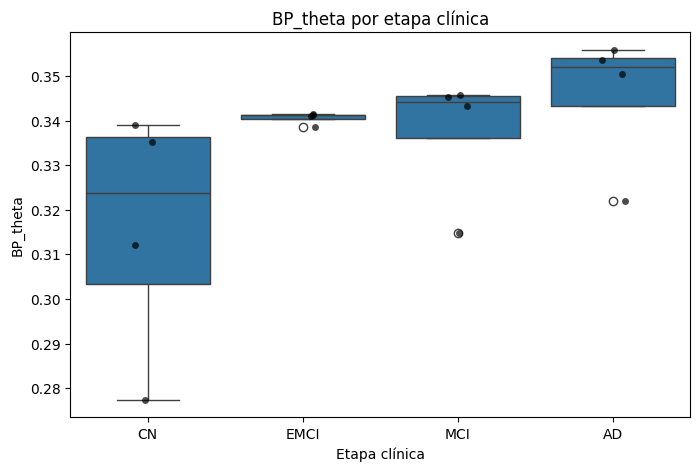

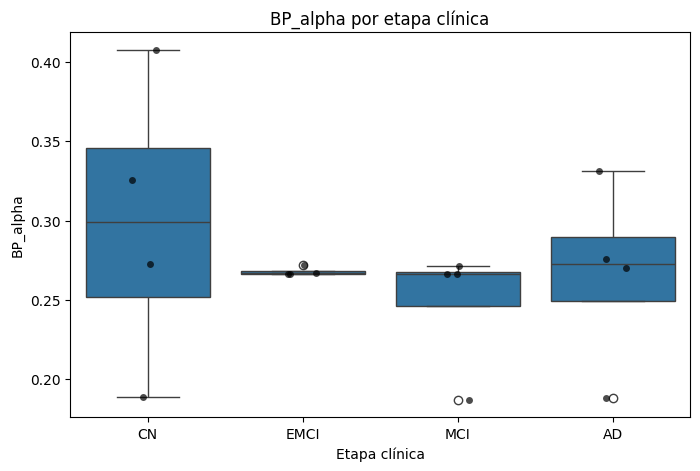

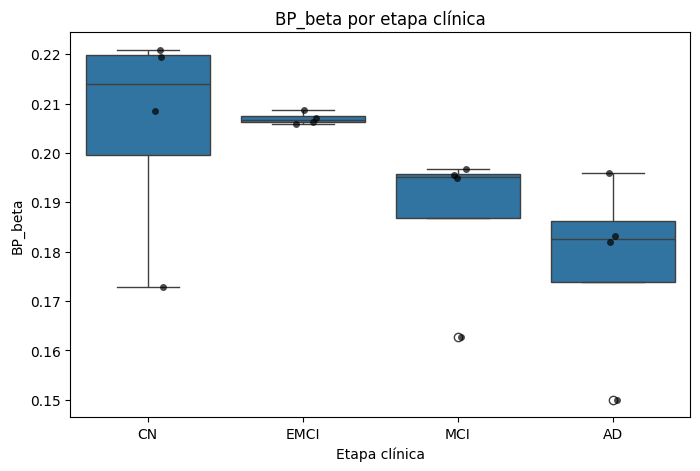

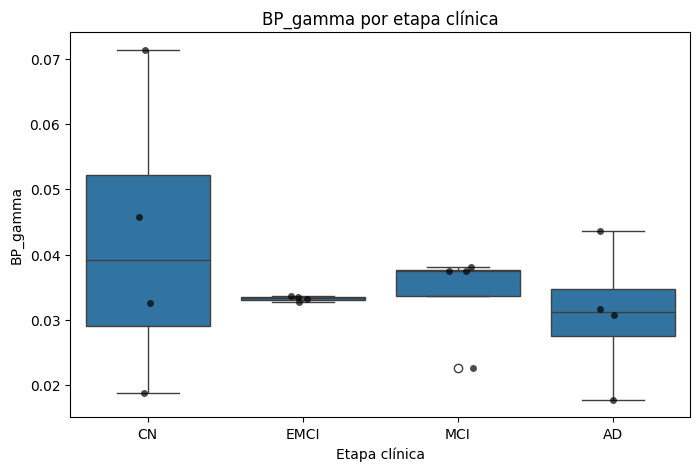

In [15]:
for variable in spectral_features:
    plot_biomarker_by_stage(
        df,
        variable,
        f"{variable} por etapa clínica"
    )

### 3. Perfil espectral

Se quiere observar cómo se distribuye la potencia entre:

delta → theta → alpha → beta → gamma

Para cada etapa clínica.

Primero calculamos el promedio:

In [16]:
spectral_mean = (
    df.groupby("label", observed=True)[spectral_features]
      .mean()
)

spectral_mean

,BP_delta,BP_theta,BP_alpha,BP_beta,BP_gamma
label,,,,,
CN,0.137985,0.315975,0.298509,0.205426,0.042106
EMCI,0.151198,0.340614,0.267939,0.207001,0.033248
MCI,0.193610,0.337287,0.247722,0.187450,0.033931
AD,0.179664,0.345464,0.266205,0.177725,0.030942


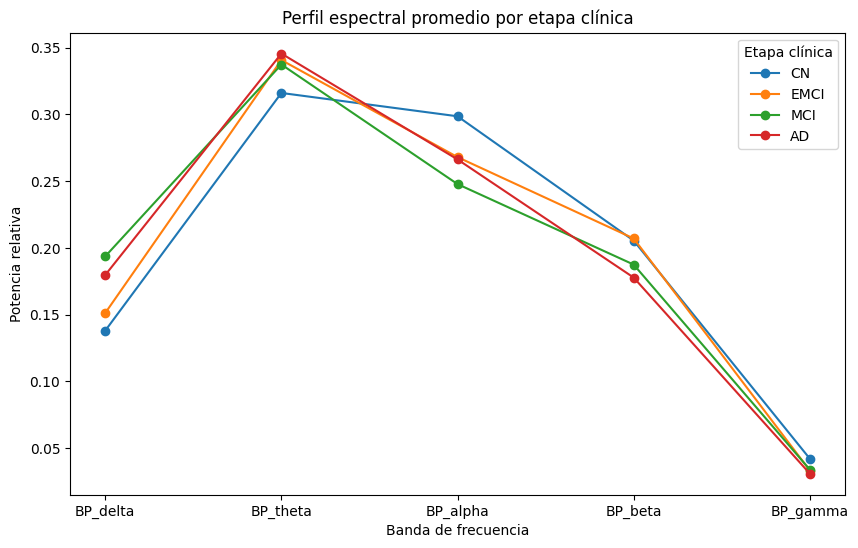

In [17]:
plt.figure(figsize=(10, 6))

for stage in orden_clinico:
    values = spectral_mean.loc[stage]

    plt.plot(
        spectral_features,
        values,
        marker="o",
        label=stage
    )

plt.title("Perfil espectral promedio por etapa clínica")
plt.xlabel("Banda de frecuencia")
plt.ylabel("Potencia relativa")

plt.legend(title="Etapa clínica")
plt.show()

> Se observa un desplazamiento del perfil espectral hacia mayores contribuciones de las bandas lentas, acompañado de una reducción de las bandas beta y gamma en las etapas de mayor severidad.

### 4. Análisis de theta_alpha_ratio



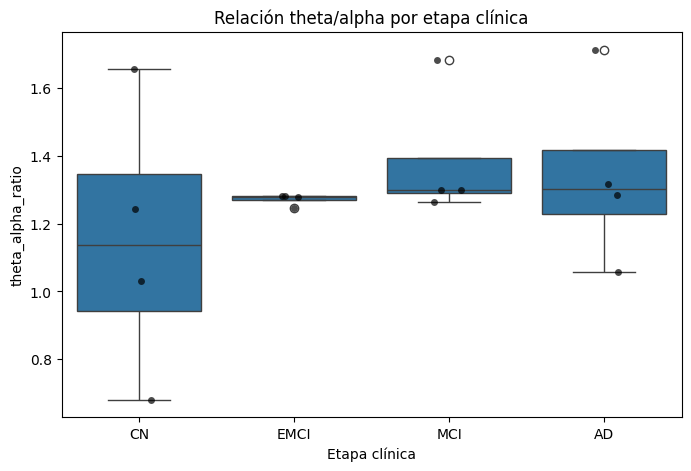

In [18]:
plot_biomarker_by_stage(
    df,
    "theta_alpha_ratio",
    "Relación theta/alpha por etapa clínica"
)

Estadísticas por grupo:

In [19]:
df.groupby("label", observed=True)["theta_alpha_ratio"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
label,,,,,
CN,1.152708,1.137437,0.407856,0.680533,1.655423
EMCI,1.271369,1.279561,0.017495,1.245165,1.281188
MCI,1.385875,1.298478,0.198394,1.264074,1.682470
AD,1.343043,1.300879,0.272383,1.057435,1.712980


### 5. Análisis de slowing

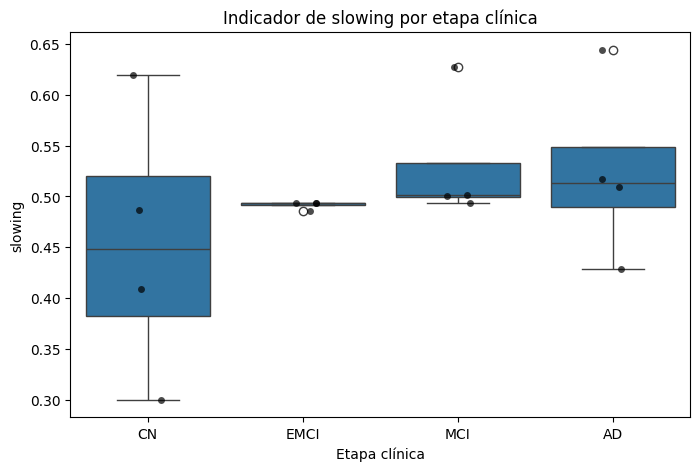

In [20]:
plot_biomarker_by_stage(
    df,
    "slowing",
    "Indicador de slowing por etapa clínica"
)

In [21]:
df.groupby("label", observed=True)["slowing"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
label,,,,,
CN,0.453960,0.447977,0.134439,0.300081,0.619806
EMCI,0.491812,0.493673,0.003971,0.485866,0.494036
MCI,0.530898,0.501174,0.064553,0.493662,0.627580
AD,0.525128,0.513556,0.088951,0.429062,0.644338


> A medida que aumenta el índice de severidad, el indicador slowing presenta una tendencia general ascendente hasta MCI y permanece elevado en AD.

### 6. Conectividad funcional

In [22]:
functional_features = [
    "FC_strength",
    "FC_clustering",
    "FC_efficiency"
]

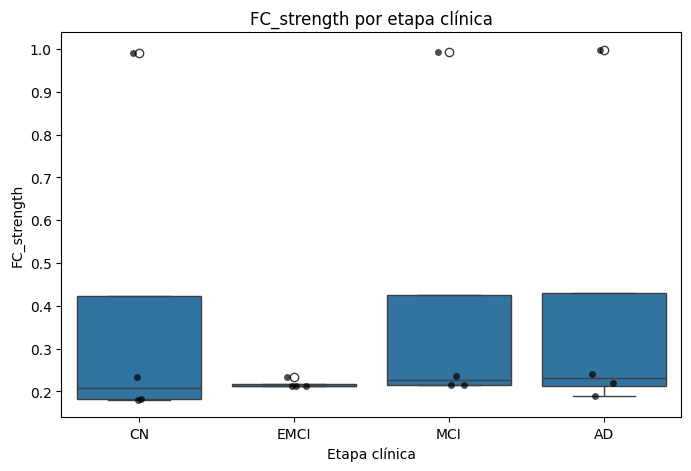

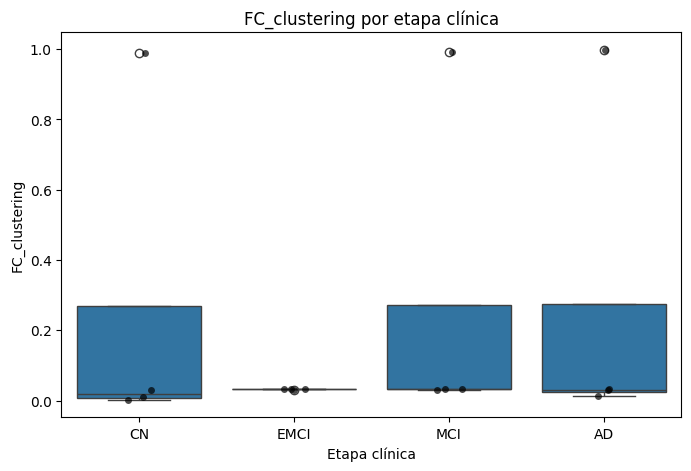

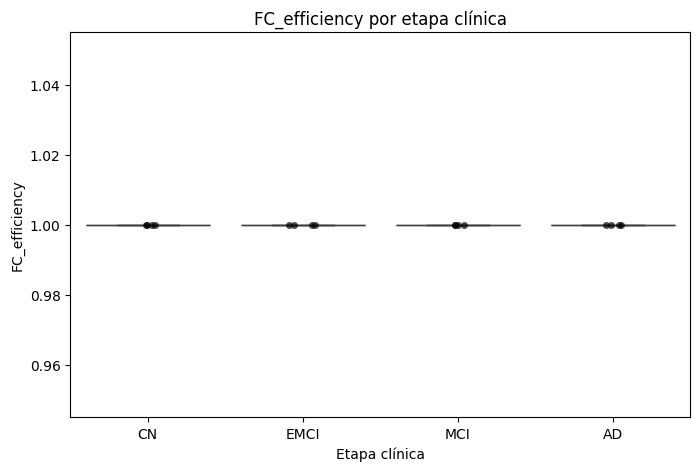

In [23]:
for variable in functional_features:
    plot_biomarker_by_stage(
        df,
        variable,
        f"{variable} por etapa clínica"
    )

In [24]:
functional_summary = (
    df.groupby("label", observed=True)[functional_features]
      .mean()
)

functional_summary

,FC_strength,FC_clustering,FC_efficiency
label,,,
CN,0.396457,0.257901,1.0
EMCI,0.218189,0.032588,1.0
MCI,0.415367,0.271911,1.0
AD,0.412690,0.268278,1.0


> Aunque se ven diferencias en los grupos para `FC_strength` y `FC_clustering` no se tiene una tendencia monotónica consistente con la severidad.


In [25]:
df["FC_efficiency"].nunique()

1

In [26]:
df["FC_efficiency"].value_counts()

,count
FC_efficiency,
1.0,16


> Para el análisis, `FC_efficiency` no aporta capacidad discriminativa en este dataset.

### 7. Conectividad estructural

In [27]:
structural_features = [
    "SC_strength",
    "SC_density"
]

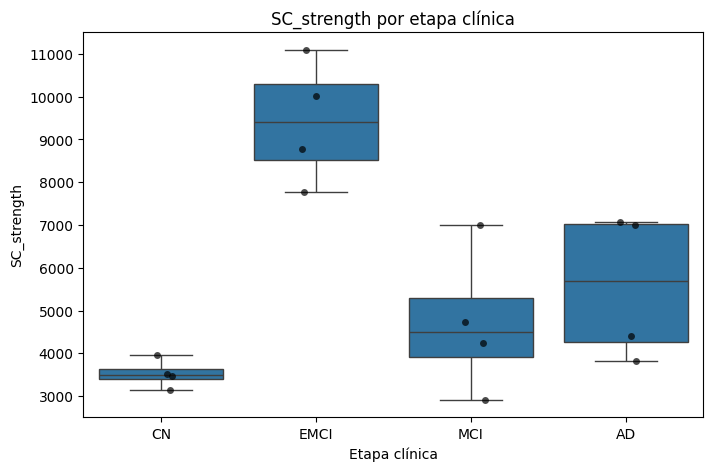

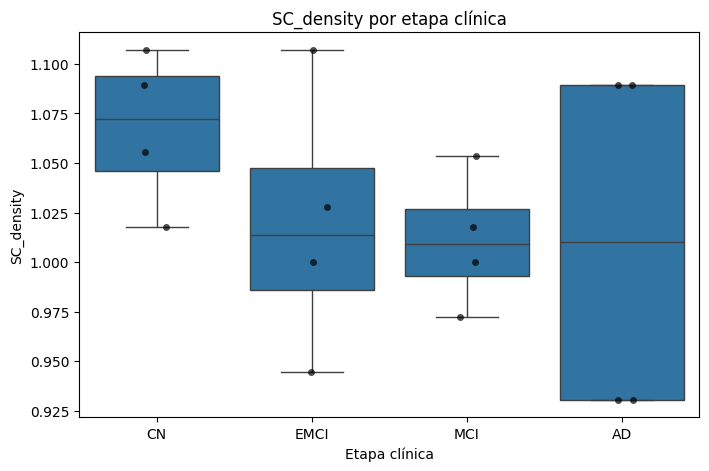

In [28]:
for variable in structural_features:
    plot_biomarker_by_stage(
        df,
        variable,
        f"{variable} por etapa clínica"
    )

In [29]:
structural_summary = (
    df.groupby("label", observed=True)[structural_features]
      .mean()
)

structural_summary

,SC_strength,SC_density
label,,
CN,3519.679543,1.067460
EMCI,9416.861786,1.019841
MCI,4727.216917,1.010913
AD,5571.211516,1.009921


> No hay una asociación lineal apreciable en este conjunto de datos con `SC_strength`.

> `SC_density` presenta una asociación negativa con el índice de severidad y muestra una disminución gradual de sus valores promedio entre las categorías clínicas.

## Análisis estadístico

### 1. Matriz de correlación

In [30]:
biomarker_features = [
    "BP_delta",
    "BP_theta",
    "BP_alpha",
    "BP_beta",
    "BP_gamma",
    "theta_alpha_ratio",
    "slowing",
    "FC_strength",
    "FC_clustering",
    "FC_efficiency",
    "SC_strength",
    "SC_density",
    "severity_index"
]

In [31]:
correlation_matrix = df[biomarker_features].corr()

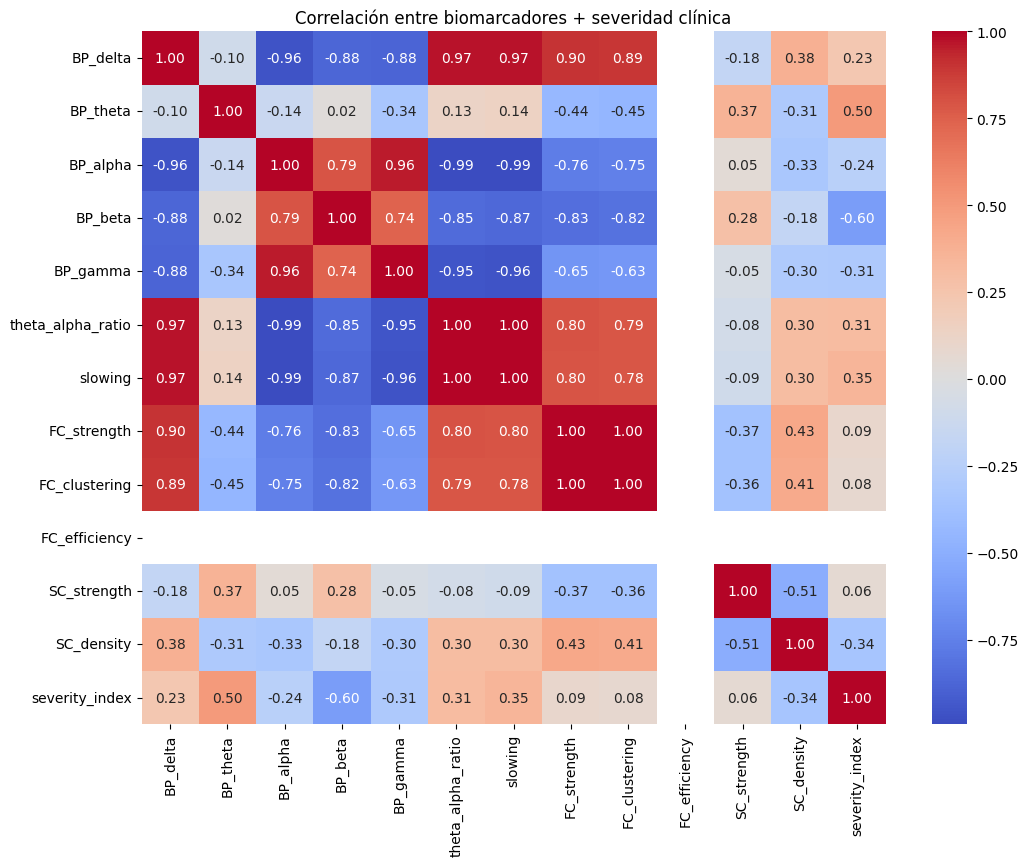

In [32]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre biomarcadores + severidad clínica")
plt.show()

### 2. Relación entre severidad y biomarcadores

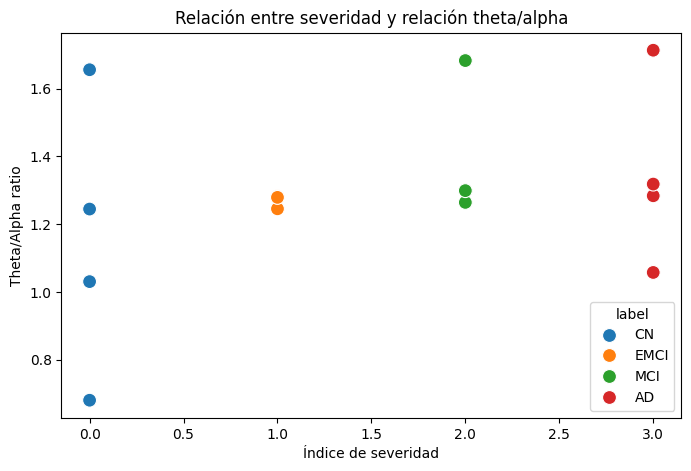

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="severity_index",
    y="theta_alpha_ratio",
    hue="label",
    s=100
)

plt.title("Relación entre severidad y relación theta/alpha")
plt.xlabel("Índice de severidad")
plt.ylabel("Theta/Alpha ratio")

plt.show()

### 3. Correlación de cada biomarcador con severity_index

In [34]:
severity_correlations = (
    df[biomarker_features]
    .corr()["severity_index"]
    .drop("severity_index")
    .sort_values(ascending=False)
)

severity_correlations

,severity_index
BP_theta,0.496301
slowing,0.347622
theta_alpha_ratio,0.312020
BP_delta,0.231610
FC_strength,0.090197
FC_clustering,0.080103
SC_strength,0.064872
BP_alpha,-0.243873
BP_gamma,-0.306166
SC_density,-0.342938


> Dentro del conjunto de datos analizado, `BP_beta` presentó la asociación lineal negativa más elevada con el índice ordinal de severidad, mientras que `BP_theta` presentó la asociación positiva más elevada.

### 4. Relación de los principales biomarcadores con la severidad

<Axes: xlabel='severity_index', ylabel='BP_beta'>

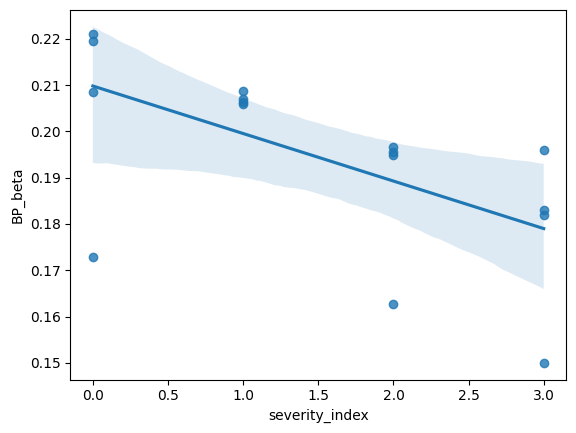

In [35]:
sns.regplot(
    data=df,
    x="severity_index",
    y="BP_beta"
)

<Axes: xlabel='severity_index', ylabel='BP_theta'>

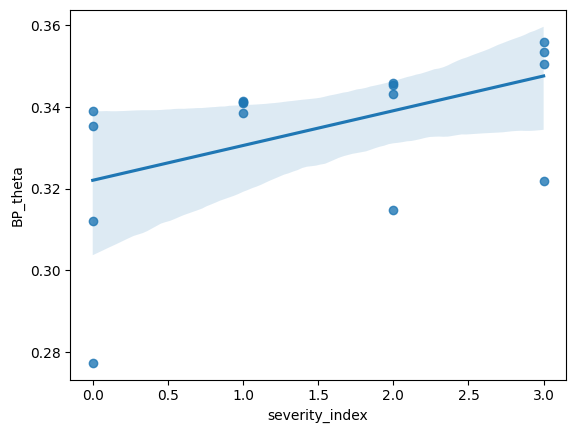

In [36]:
sns.regplot(
    data=df,
    x="severity_index",
    y="BP_theta"
)

### 5. Análisis estadístico con Spearman

Se decidió hacer un análisis complementario con Spearman, ya que, el índice de severidad es una variable ordinal.

In [37]:
from scipy.stats import spearmanr

results = []

for feature in biomarker_features[:-1]:
    correlation, p_value = spearmanr(
        df[feature],
        df["severity_index"]
    )

    results.append({
        "Biomarcador": feature,
        "Spearman_rho": correlation,
        "p_value": p_value
    })

spearman_results = pd.DataFrame(results)

spearman_results.sort_values(
    "Spearman_rho",
    ascending=False
)

/tmp/ipykernel_2641/2306388726.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(


,Biomarcador,Spearman_rho,p_value
1,BP_theta,0.654846,0.005906
6,slowing,0.497198,0.050059
0,BP_delta,0.485071,0.056848
5,theta_alpha_ratio,0.472944,0.064294
7,FC_strength,0.339550,0.198211
10,SC_strength,0.181902,0.500156
8,FC_clustering,0.145521,0.590753
2,BP_alpha,-0.181902,0.500156
4,BP_gamma,-0.242536,0.365430
11,SC_density,-0.365963,0.163308


> Como se observó anteriormente `FC_efficiency` presentó un valor constante en todos los registros, por lo que no fue posible calcular su correlación con el índice de severidad. Debido a la ausencia de variabilidad, esta variable no aporta información discriminativa dentro del conjunto analizado.

> En estos datos, los valores de `BP_theta` tienden a ser mayores conforme aumenta el nivel ordinal de severidad.

> En estos datos, `BP_beta` presenta una asociación negativa con la severidad: los valores tienden a disminuir a medida que aumenta severity_index.

> `slowing` presentó una asociación positiva moderada con la severidad, aunque su p-value se encuentra muy próximo al umbral convencional de 0.05.

> `theta_alpha_ratio` mostró una tendencia positiva con la severidad, aunque la evidencia estadística fue insuficiente para considerarla significativa bajo un umbral de 0.05.

### 6. Corrección por comparaciones múltiples con Benjamini-Hochberg (FDR)

In [38]:
from statsmodels.stats.multitest import multipletests

# Excluir resultados sin p-value válido
valid_results = spearman_results.dropna(subset=["p_value"]).copy()

# Corrección de Benjamini-Hochberg
valid_results["p_value_adjusted"] = multipletests(
    valid_results["p_value"],
    method="fdr_bh"
)[1]

valid_results = valid_results.sort_values("p_value_adjusted")

valid_results

,Biomarcador,Spearman_rho,p_value,p_value_adjusted
1,BP_theta,0.654846,0.005906,0.032480
3,BP_beta,-0.666973,0.004770,0.032480
0,BP_delta,0.485071,0.056848,0.141446
5,theta_alpha_ratio,0.472944,0.064294,0.141446
6,slowing,0.497198,0.050059,0.141446
11,SC_density,-0.365963,0.163308,0.299398
7,FC_strength,0.339550,0.198211,0.311475
4,BP_gamma,-0.242536,0.365430,0.502467
2,BP_alpha,-0.181902,0.500156,0.550171
10,SC_strength,0.181902,0.500156,0.550171


In [39]:
key_features = [
    "BP_theta",
    "BP_beta",
    "slowing",
    "theta_alpha_ratio",
    "SC_density"
]

group_summary = (
    df.groupby("label", observed=True)[key_features]
      .agg(["mean", "median", "std"])
)

group_summary

BP_theta                       BP_beta                       slowing  \
           mean    median       std      mean    median       std      mean   
label                                                                         
CN     0.315975  0.323702  0.028360  0.205426  0.213944  0.022391  0.453960   
EMCI   0.340614  0.341219  0.001334  0.207001  0.206703  0.001241  0.491812   
MCI    0.337287  0.344297  0.015038  0.187450  0.195226  0.016539  0.530898   
AD     0.345464  0.352031  0.015885  0.177725  0.182483  0.019529  0.525128   

                          theta_alpha_ratio                     SC_density  \
         median       std              mean    median       std       mean   
label                                                                        
CN     0.447977  0.134439          1.152708  1.137437  0.407856   1.067460   
EMCI   0.493673  0.003971          1.271369  1.279561  0.017495   1.019841   
MCI    0.501174  0.064553          1.385875  1.298478  0.198394   1.010913   
AD     0.513556  0.088951          1.343043  1.300879  0.272383   1.009921   

                           
         median       std  
label                      
CN     1.072421  0.039384  
EMCI   1.013889  0.067732  
MCI    1.008929  0.034079  
AD     1.009921  0.091643

> En el conjunto analizado, `BP_beta` presentó una asociación negativa con el índice ordinal de severidad, mientras que `BP_theta` presentó una asociación positiva. Ambas asociaciones permanecieron por debajo de 0.05 después de aplicar la corrección de Benjamini-Hochberg para comparaciones múltiples.

> `slowing` mostró una asociación positiva moderada con la severidad, pero esta asociación no se mantuvo después de corregir por comparaciones múltiples, por lo que no se considera estadísticamente significativo. Lo mismo ocurre con `SC_density`.

### 7. Comprobación de valores individuales de BP_theta y BP_beta

Para comprobar si las asociaciones están siendo impulsadas por algún registro extremo.

In [40]:
df[
    [
        "subject_id",
        "label",
        "severity_index",
        "BP_theta",
        "BP_beta"
    ]
].sort_values(
    ["severity_index", "subject_id"]
)

,subject_id,label,severity_index,BP_theta,BP_beta
0,CN_1,CN,0,0.335303,0.219438
1,CN_2,CN,0,0.277387,0.220922
2,CN_3,CN,0,0.339109,0.208451
3,CN_4,CN,0,0.312101,0.172892
4,EMCI_1,EMCI,1,0.341394,0.205890
5,EMCI_2,EMCI,1,0.338622,0.208708
6,EMCI_3,EMCI,1,0.341334,0.206318
7,EMCI_4,EMCI,1,0.341105,0.207088
8,MCI_1,MCI,2,0.345372,0.195544
9,MCI_2,MCI,2,0.343221,0.196681


> `BP_theta` presentó una asociación positiva con el índice ordinal de severidad (ρ = 0.655; p ajustado ≈ 0.033). Los valores promedio aumentaron de 0.316 en CN a 0.345 en AD.

> `BP_beta` presentó una asociación negativa con el índice ordinal de severidad (ρ = −0.667; p ajustado ≈ 0.033). Los valores promedio disminuyeron de 0.205 en CN a 0.178 en AD.

> Estos patrones deben interpretarse como asociaciones exploratorias debido al reducido tamaño de muestra y al carácter derivado/simulado de las características analizadas.

###  8. Comparación de BP_theta y BP_beta entre etapas

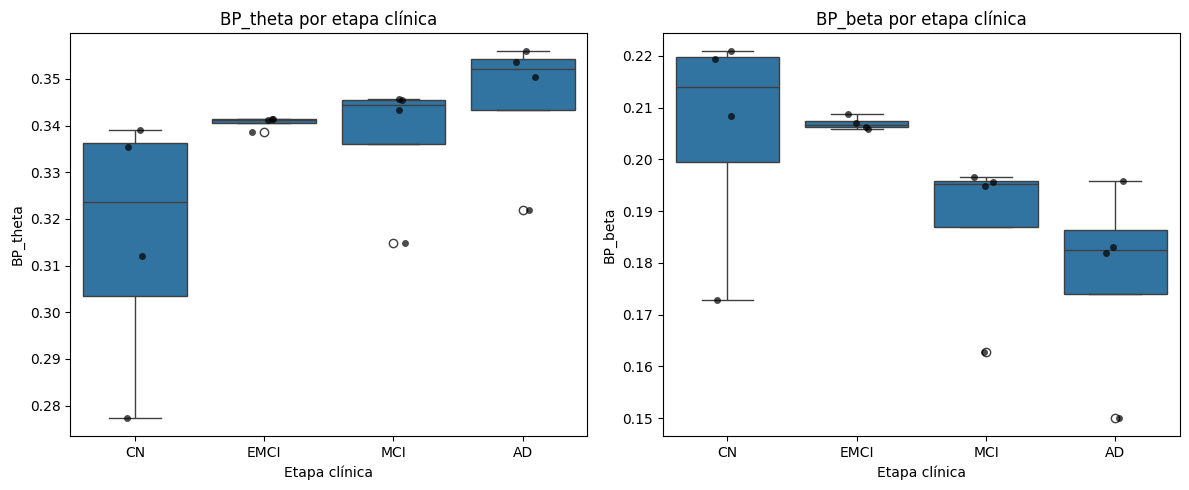

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x="label",
    y="BP_theta",
    order=orden_clinico,
    ax=axes[0]
)

sns.stripplot(
    data=df,
    x="label",
    y="BP_theta",
    order=orden_clinico,
    color="black",
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("BP_theta por etapa clínica")
axes[0].set_xlabel("Etapa clínica")
axes[0].set_ylabel("BP_theta")


sns.boxplot(
    data=df,
    x="label",
    y="BP_beta",
    order=orden_clinico,
    ax=axes[1]
)

sns.stripplot(
    data=df,
    x="label",
    y="BP_beta",
    order=orden_clinico,
    color="black",
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title("BP_beta por etapa clínica")
axes[1].set_xlabel("Etapa clínica")
axes[1].set_ylabel("BP_beta")

plt.tight_layout()
plt.show()

**¿Los valores de BP_theta y BP_beta difieren entre CN, EMCI, MCI y AD?**

Como se tiene solamente 4 observaciones por grupo y no se puede asumir una distribución normal con tanta confianza, se utiliza la prueba Kruskal-Wallis.

In [42]:
from scipy.stats import kruskal

In [43]:
groups_theta = [
    df.loc[df["label"] == stage, "BP_theta"]
    for stage in orden_clinico
]

groups_beta = [
    df.loc[df["label"] == stage, "BP_beta"]
    for stage in orden_clinico
]

La hipótesis que se está evaluando es:

- H₀: las distribuciones de los grupos no presentan diferencias.
- H₁: al menos uno de los grupos presenta una distribución diferente.

Umbral exploratorio = 0.05

In [44]:
h_theta, p_theta = kruskal(*groups_theta)

h_beta, p_beta = kruskal(*groups_beta)

print(f"BP_theta: H = {h_theta:.4f}, p = {p_theta:.4f}")
print(f"BP_beta:  H = {h_beta:.4f}, p = {p_beta:.4f}")

BP_theta: H = 6.7500, p = 0.0803
BP_beta:  H = 7.6544, p = 0.0537


In [45]:
print("BP_theta")
print(f"Media CN:   {df[df['label'] == 'CN']['BP_theta'].mean():.4f}")
print(f"Media EMCI: {df[df['label'] == 'EMCI']['BP_theta'].mean():.4f}")
print(f"Media MCI:  {df[df['label'] == 'MCI']['BP_theta'].mean():.4f}")
print(f"Media AD:   {df[df['label'] == 'AD']['BP_theta'].mean():.4f}")

print("\nBP_beta")
print(f"Media CN:   {df[df['label'] == 'CN']['BP_beta'].mean():.4f}")
print(f"Media EMCI: {df[df['label'] == 'EMCI']['BP_beta'].mean():.4f}")
print(f"Media MCI:  {df[df['label'] == 'MCI']['BP_beta'].mean():.4f}")
print(f"Media AD:   {df[df['label'] == 'AD']['BP_beta'].mean():.4f}")

BP_theta
Media CN:   0.3160
Media EMCI: 0.3406
Media MCI:  0.3373
Media AD:   0.3455

BP_beta
Media CN:   0.2054
Media EMCI: 0.2070
Media MCI:  0.1874
Media AD:   0.1777


In [46]:
statistical_tests = pd.DataFrame({
    "Biomarcador": ["BP_theta", "BP_beta"],
    "Kruskal_H": [h_theta, h_beta],
    "p_value": [p_theta, p_beta]
})

statistical_tests

,Biomarcador,Kruskal_H,p_value
0,BP_theta,6.750000,0.080308
1,BP_beta,7.654412,0.053721


In [47]:
statistical_tests["Interpretacion"] = np.where(
    statistical_tests["p_value"] < 0.05,
    "Diferencia estadísticamente significativa",
    "No significativa (p >= 0.05)"
)

statistical_tests

,Biomarcador,Kruskal_H,p_value,Interpretacion
0,BP_theta,6.750000,0.080308,No significativa (p >= 0.05)
1,BP_beta,7.654412,0.053721,No significativa (p >= 0.05)


## Hallazgos principales

### BP_theta

BP_theta presentó una asociación positiva con el índice ordinal de severidad
(ρ = 0.655; p ajustado ≈ 0.033).

Los valores promedio fueron:

- CN: 0.316
- EMCI: 0.341
- MCI: 0.337
- AD: 0.345

La prueba de Kruskal-Wallis no detectó diferencias estadísticamente
significativas entre los cuatro grupos (H = 6.750; p = 0.080).



### BP_beta

BP_beta presentó una asociación negativa con el índice ordinal de severidad
(ρ = -0.667; p ajustado ≈ 0.033).

Los valores promedio fueron:

- CN: 0.205
- EMCI: 0.207
- MCI: 0.187
- AD: 0.178

La prueba de Kruskal-Wallis tampoco alcanzó el umbral convencional de
significancia (H = 7.654; p = 0.054).

### Otros biomarcadores

slowing y theta_alpha_ratio mostraron tendencias positivas con el índice de
severidad, mientras que SC_density mostró una tendencia negativa. Sin embargo,
estas asociaciones no permanecieron estadísticamente significativas después
de la corrección por comparaciones múltiples.

FC_efficiency presentó un valor constante en todos los registros y, por tanto,
no fue posible calcular su correlación con severity_index.

## Limitaciones

- El dataset contiene únicamente 16 registros, con cuatro observaciones por
  etapa clínica.
- Los resultados tienen carácter exploratorio y no deben interpretarse como
  evidencia de capacidad diagnóstica.
- Las características analizadas son derivadas de un modelo neurocomputacional
  y de señales M/EEG simuladas descritas en el trabajo académico.
- El tamaño reducido de la muestra limita la generalización de los resultados.
- Las asociaciones estadísticas no implican relaciones causales.
- `FC_efficiency` presentó un valor constante y no aportó variabilidad para el
  análisis de correlación.
- Los datos individuales originales de ADNI no se incluyen debido a las
  condiciones de acceso y uso de dichos datos.

## Conclusiones

El análisis exploratorio permitió identificar patrones diferenciados en los
biomarcadores espectrales según el índice ordinal de severidad.

Las asociaciones más destacadas correspondieron a BP_theta, con una relación
positiva, y BP_beta, con una relación negativa. Ambas asociaciones conservaron
evidencia estadística después de aplicar una corrección por comparaciones
múltiples.

Sin embargo, la comparación global entre las cuatro etapas mediante
Kruskal-Wallis no mostró diferencias estadísticamente significativas para
ninguna de estas dos variables. Por ello, los resultados deben interpretarse
como patrones exploratorios dentro del conjunto analizado y no como evidencia
de capacidad diagnóstica o predictiva.

El proyecto demuestra el uso de Python para realizar procesos de carga,
validación, análisis exploratorio, visualización, análisis de correlaciones y
pruebas estadísticas sobre datos científicos.